# LLM-inference serving: will this request miss its SLO?

Most calculators in this library return raw **moments** of the waiting/sojourn time -- mean,
variance, skew. An SLA ("95% of requests get a first token within 2 seconds") is a statement
about the **tail** of that distribution, not its mean. `most_queue.theory.utils.sla` turns the
moments you already have into a deadline-violation probability `P(W > D)` or an SLO quantile
`D_p`, by fitting a 2-3 moment distribution (H2 for cv >= 1, Gamma for cv < 1) and reading off its
closed-form tail.

We model GPU batch-inference serving as a bursty **MAP(MMPP-2)/PH/1** queue: request arrivals are
autocorrelated (not Poisson -- LLM-serving traffic comes in bursts), and the batch-inference
service time is PH-fitted with realistic variability. This is the composite example behind
`examples/llm_serving_slo.py` and `docs/models/sla.md`; see
`docs/research/sla-deadline-queueing-2026.md` for the literature behind it (QUARTZ, Hermes,
TailGuard/TPDS 2025).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from most_queue.random.distributions import H2Distribution
from most_queue.random.map_ph import MAP, PHDistribution
from most_queue.theory.matrix.map_ph1 import MapPh1Calc
from most_queue.theory.priority.non_preemptive.mg1 import MG1NonPreemptiveCalc
from most_queue.theory.utils.sla import deadline_violation_prob, slo_quantile

plt.rcParams.update({"figure.figsize": (8, 5), "axes.grid": True, "font.size": 11})

# Batch-inference service: mean 1.0 time unit, cv=1.5 (batching variability).
SERVICE_MEAN = 1.0
SERVICE_CV = 1.5

# MMPP-2 burstiness shape, scaled below to hit a target utilization.
BASE_RATES = [2.0, 0.4]
PHASE_Q = np.array([[-0.2, 0.2], [0.3, -0.3]])

# TTFT deadline: 3x mean service time.
DEADLINE = 3.0 * SERVICE_MEAN


def service_ph():
    h2 = H2Distribution.get_params_by_mean_and_cv(SERVICE_MEAN, SERVICE_CV)
    return PHDistribution.from_h2(h2)


def mmpp_for_rho(rho):
    base = MAP.mmpp(BASE_RATES, PHASE_Q)
    scale = (rho / SERVICE_MEAN) / MAP.arrival_rate(base)
    return MAP.mmpp([r * scale for r in BASE_RATES], PHASE_Q)

## SLO-violation probability vs load

For each target utilization `rho`, solve the exact MAP/PH/1 QBD for the waiting-time moments
(`MapPh1Calc`), then read off `P(TTFT > DEADLINE)` and the 95th-percentile deadline via the SLA
layer -- no simulation needed.

In [2]:
rhos = [0.5, 0.6, 0.7, 0.8, 0.85, 0.9, 0.93, 0.95]
ph_srv = service_ph()

rows = []
for rho in rhos:
    calc = MapPh1Calc()
    calc.set_sources(mmpp_for_rho(rho))
    calc.set_servers(ph_srv)
    w = calc.run().w
    rows.append((rho, deadline_violation_prob(w, DEADLINE), slo_quantile(w, 0.05)))

for rho, p_violation, d95 in rows:
    print(f"rho={rho:.2f}  P(TTFT > {DEADLINE:.1f}) = {p_violation:.4f}  D_0.05 = {d95:.2f}")

rho=0.50  P(TTFT > 3.0) = 0.2426  D_0.05 = 9.24

rho=0.60  P(TTFT > 3.0) = 0.3430  D_0.05 = 12.73

rho=0.70  P(TTFT > 3.0) = 0.4677  D_0.05 = 18.46

rho=0.80  P(TTFT > 3.0) = 0.6184  D_0.05 = 29.87

rho=0.85  P(TTFT > 3.0) = 0.7039  D_0.05 = 41.29

rho=0.90  P(TTFT > 3.0) = 0.7960  D_0.05 = 64.13

rho=0.93  P(TTFT > 3.0) = 0.8545  D_0.05 = 93.51

rho=0.95  P(TTFT > 3.0) = 0.8948  D_0.05 = 132.69

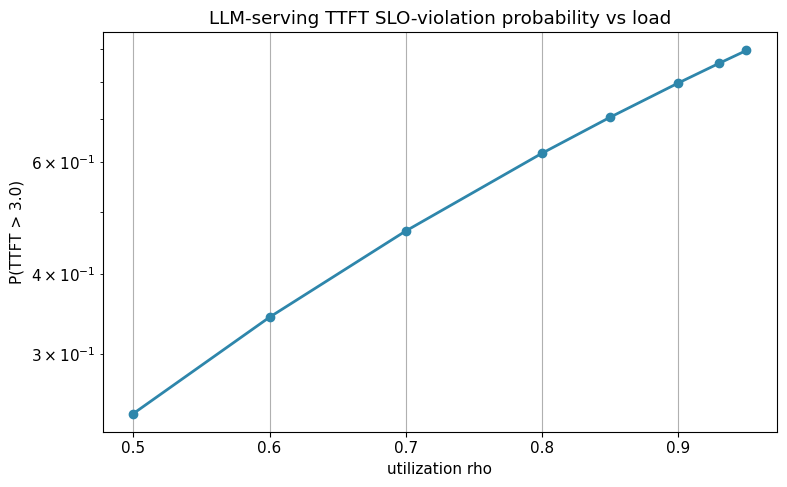

In [3]:
rho_vals, p_vals, _ = zip(*rows)

fig, ax = plt.subplots()
ax.semilogy(rho_vals, p_vals, color="#2e86ab", marker="o", lw=2)
ax.set_xlabel("utilization rho")
ax.set_ylabel(f"P(TTFT > {DEADLINE:.1f})")
ax.set_title("LLM-serving TTFT SLO-violation probability vs load")
plt.tight_layout()
plt.show()

The violation probability rises sharply as `rho` approaches the stability boundary -- the same
qualitative shape reported by SLO-aware LLM-serving papers (QUARTZ, Hermes). This is *not* a plot
of the mean response time: it directly answers the SLA question a dispatcher cares about.

## Two SLO tiers: premium vs free

Suppose the same server is shared by a premium tier (30% of traffic, served with non-preemptive
priority) and a free tier (70%). `MapPh1PriorityCalc` (the MAP+PH priority calculator) only
returns the *mean* waiting time per class -- not enough raw moments for the SLA tail layer -- so
here we use Poisson-split arrivals with `MG1NonPreemptiveCalc`, which does return full moments per
class, on the same PH-fitted batch-inference service distribution.

In [4]:
rho = 0.9
premium_share = 0.3

total_lambda = rho / SERVICE_MEAN
lambdas = [premium_share * total_lambda, (1.0 - premium_share) * total_lambda]
b = PHDistribution.calc_theory_moments(ph_srv, 4)

calc = MG1NonPreemptiveCalc()
calc.set_sources(lambdas)
calc.set_servers([b, b])
results = calc.run()

for name, k in (("premium", 0), ("free", 1)):
    p_violation = deadline_violation_prob(results.w[k], DEADLINE)
    print(f"{name:>8}: P(TTFT > {DEADLINE:.1f}) = {p_violation:.4f}")

 premium: P(TTFT > 3.0) = 0.2304

    free: P(TTFT > 3.0) = 0.8001

The premium tier's SLO-violation probability stays well below the free tier's, even though both
share the exact same server and service-time distribution -- the entire effect comes from
scheduling priority, not from provisioning extra capacity.

See also: `docs/models/sla.md`, `examples/llm_serving_slo.py`, and
`tests/test_sla_vs_sim_*.py` for the discrete-event cross-validation of this fit-based approach.